In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
real_path = "../frames/real_frames"
fake_path = "../frames/fake_frames"

In [4]:
# Custom Dataset
class DeepfakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform

        for img in os.listdir(real_dir):
            self.images.append(os.path.join(real_dir, img))
            self.labels.append(0)

        for img in os.listdir(fake_dir):
            self.images.append(os.path.join(fake_dir, img))
            self.labels.append(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
    
        img_path = self.images[idx]
    
        img = cv2.imread(img_path)
    
        if img is None:
            print("Skipping corrupted image:", img_path)
            img = np.zeros((224,224,3), dtype=np.uint8)
    
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
        if self.transform:
            img = self.transform(img)
    
        label = torch.tensor(self.labels[idx])
    
        return img, label

In [5]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [6]:
dataset = DeepfakeDataset(real_path, fake_path, transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Total images:", len(dataset))

Total images: 68491


In [7]:
# CNN Model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel,self).__init__()

        self.conv1 = nn.Conv2d(3,16,3)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16,32,3)

        self.fc1 = nn.Linear(32*54*54,128)
        self.fc2 = nn.Linear(128,2)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0),-1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [8]:
# Initialize Model
model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('Model ready')

Model ready


In [9]:
# Training Loop
epochs = 5

model.train()

for epoch in range(epochs):

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    print(f'Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.2f}%')

Epoch [1/5] Loss: 0.2884 Accuracy: 91.07%
Epoch [2/5] Loss: 0.2393 Accuracy: 92.27%
Epoch [3/5] Loss: 0.2306 Accuracy: 92.44%
Epoch [4/5] Loss: 0.2268 Accuracy: 92.56%
Epoch [5/5] Loss: 0.2238 Accuracy: 92.57%


In [12]:
img_name = os.listdir("../frames/real_frames")[0]

img_path = "../frames/real_frames/" + img_name

print("Testing image:", img_path)

test_img = cv2.imread(img_path)

test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

test_img = transform(test_img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(test_img)

prediction = torch.argmax(output)

print("Prediction:", prediction.item())

Testing image: ../frames/real_frames/01__exit_phone_room.mp4_frame_0.jpg
Prediction: 0


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

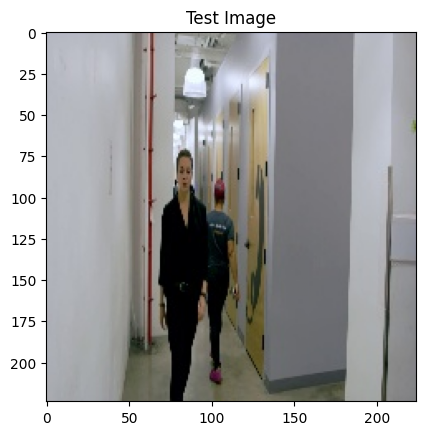

In [16]:
plt.imshow(test_img.cpu().squeeze().permute(1,2,0))
plt.title("Test Image")
plt.axis("on")

In [13]:
img_name = os.listdir("../frames/fake_frames")[0]

img_path = "../frames/fake_frames/" + img_name

print("Testing image:", img_path)

test_img = cv2.imread(img_path)

test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

test_img = transform(test_img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(test_img)

prediction = torch.argmax(output)

print("Prediction:", prediction.item())

Testing image: ../frames/fake_frames/01_02__exit_phone_room__YVGY8LOK.mp4_frame_0.jpg
Prediction: 1


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

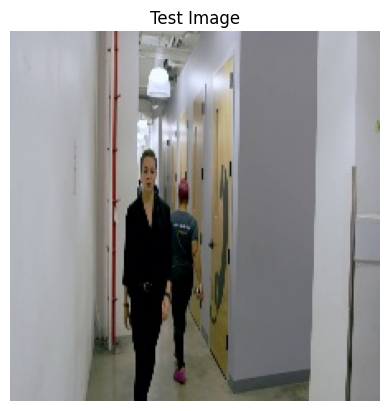

In [14]:
plt.imshow(test_img.cpu().squeeze().permute(1,2,0))
plt.title("Test Image")
plt.axis("off")